# DP-SGD on Criteo

This notebook runs DP-SGD (Abadi et al., *Deep Learning with Differential
Privacy*, 2016, [arXiv:1607.00133](https://arxiv.org/abs/1607.00133)) end to
end on Criteo click-through data: a logistic regression trained for 10,000
steps at ε = 3, δ = 1e-6, with the clipping norm and the learning rate picked
by a nine-point sweep. It exercises the loader, the accountant in both
directions, the training loop and the reference model.

In [1]:
import time
from typing import NamedTuple

import jax
import matplotlib.pyplot as plt
import numpy as np

from dimma.accounting.sampling import (
    PoissonGaussianSchedule,
    calibrate_noise_multiplier,
    poisson_gaussian_epsilon,
)
from dimma.algorithms.dp_sgd import train as dp_sgd
from dimma.core import updates
from dimma.datasets.criteo import load_criteo
from dimma.metrics.calibration import (
    calibration_ratio,
    expected_calibration_error,
    reliability_curve,
)
from dimma.metrics.scoring import log_loss, normalized_entropy
from dimma.models.logreg import forward, init_params
from dimma.models.losses import per_sample_bce_loss

DEVICE = "gpu" if any(d.platform == "gpu" for d in jax.devices()) else "cpu"
print(f"jax devices: {jax.devices()}  ->  DEVICE = {DEVICE!r}")

# Figure palette. Blue carries the private run and every calibration number
# read off it, orange the noiseless control, aqua the operating-point panel.
# The three clear the colour-vision and normal-vision separation floors as a
# set; aqua sits under 3:1 against white, which is why every point it draws
# is also printed as a table above the figure.
INK, MUTED, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"
PRIVATE_C, CONTROL_C = "#2a78d6", "#eb6834"
LOSS_C = ECE_C = PRIVATE_C
RECALL_C = "#1baf7a"

jax devices: [CudaDevice(id=0)]  ->  DEVICE = 'gpu'


In [2]:
TARGET_DELTA = 1e-6
TARGET_EPSILON = 3.0
STEPS = 10_000
EXPECTED_BATCH_SIZE = 1024

CLIP_NORMS = (3.5, 4.25, 5.0)
LEARNING_RATES = (0.01, 0.1, 0.5)

FEATURE_NORM_BOUND = None

## 1. Data

Criteo click-through data, all 39 features: the 13 integer columns and the 26
categorical ones. The split is deterministic given `seed` and `test_fraction`,
so every run below sees exactly the same rows; the preprocessing applied is
recorded in the metadata printed below.

In [3]:
split = load_criteo(features="all", preprocess=True, standardize=True,
                    download=False, seed=0,
                    device=DEVICE,
                    feature_norm_bound=FEATURE_NORM_BOUND
                    )

n_train, n_features = split.x_train.shape
base_rate = float(split.y_test.mean())
print(f"train {split.x_train.shape}   test {split.x_test.shape}")
print(f"label base rate: {float(split.y_train.mean()):.4f} train, "
      f"{base_rate:.4f} test")
print(f"PR-AUC floor (a random ranking scores the base rate): {base_rate:.4f}")

criteo: 39 features. I1-I13: NaN filled with the train-split median, clipped below at 0, log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26: each category ID replaced by that category's relative frequency in the train split, with categories unseen in training encoded as 0.0. Every column then standardized by the train-split mean and standard deviation.


train (800000, 39)   test (200000, 39)
label base rate: 0.2510 train, 0.2520 test
PR-AUC floor (a random ranking scores the base rate): 0.2520


The preprocessing statistics — the medians, the means, the standard deviations
— are fitted on the training split and accounted for in no privacy budget. The
ε reported here covers the training loop and nothing else.

## 2. Calibrating the budget

`calibrate_noise_multiplier` runs the accountant backwards: given a target
`(ε, δ)` and the shape of the run — the sampling rate `q` over `STEPS` steps —
it returns the smallest noise multiplier that meets the budget. It takes a
*builder*, a function from a candidate multiplier to the release schedules a
run would have at that multiplier, because a method may release on more than
one; plain DP-SGD has exactly one, so the builder returns a single-entry list.

In [4]:
q = EXPECTED_BATCH_SIZE / n_train
print(f"sampling rate q = {q:.6f}, over {STEPS} steps")

t0 = time.time()
sigma = calibrate_noise_multiplier(
    lambda multiplier: [PoissonGaussianSchedule(q, multiplier, STEPS)],
    TARGET_EPSILON, TARGET_DELTA,
)
print(f"noise multiplier sigma = {sigma:.6f}   ({time.time() - t0:.1f}s)")

sampling rate q = 0.001280, over 10000 steps
noise multiplier sigma = 0.682662   (0.2s)


The reporting direction, on the multiplier just calibrated: it should land at
or just under the target. The clipping norm does not enter — clipping makes the
sensitivity `C` and the noise scale `σ · C`, so the ratio the accountant sees is
the same at every `C` — and every run in the sweep below spends exactly this ε.

In [5]:
spent = poisson_gaussian_epsilon(q, sigma, STEPS, TARGET_DELTA)
print(f"epsilon at that multiplier = {spent:.6f}  (target {TARGET_EPSILON})")
assert spent <= TARGET_EPSILON + 1e-9

epsilon at that multiplier = 2.999999  (target 3.0)


## 3. Training, and the operating point

`train` takes a per-sample loss over arbitrary pytrees and never imports the
model, so the model and the algorithm meet only at this call. It returns
neither optimizer state nor a privacy cost: the first would let a caller resume
a run and replay its noise stream from the start, and the second is the
accountant's job.

**The threshold.** At a 25% base rate a calibrated model rarely emits `p > 0.5`
at all, so that cut would report the base rate rather than the classifier.
Every confusion matrix below instead flags a record when the model puts it
above the **training-split base rate** — one number, fixed before any run, and a
training-split statistic rather than a further read of the test labels.

**The five numbers.** All but PR-AUC come from `dimma.metrics`, which carries
the reasoning; the reason for reporting each one here is below.

- **Log-loss** — the objective the loop descends, so selection and training
  agree on what better means.
- **Normalized entropy** — log-loss over the entropy of the base rate, so 1.0
  is the constant predictor and the distance below it is the share of the
  available uncertainty removed (He et al., *Practical Lessons from Predicting
  Clicks on Ads at Facebook*, ADKDD 2014).
- **Calibration ratio** — observed clicks over predicted clicks; 1.0 is
  calibrated, and a bid built on a model at 0.9 overpays by about 11%.
- **ECE**, at 15 equal-mass bins — per-example clipping, not the noise, is the
  documented cause of miscalibration under DP (Zhang et al., *A Closer Look at
  the Calibration of Differentially Private Learners*,
  [arXiv:2210.08248](https://arxiv.org/abs/2210.08248)), which is why the sweep
  below is over `C`. The estimator is biased upward, so these compare only
  against each other.
- **PR-AUC** — the ranking read, floored at the base rate. It stays a local
  helper because `dimma.metrics` offers no metric that reads rank alone.

In [6]:
Y_TEST = np.asarray(split.y_test, dtype=np.float64)
THRESHOLD = float(split.y_train.mean())
THRESHOLD_LOGIT = float(np.log(THRESHOLD / (1.0 - THRESHOLD)))
N_BINS = 15
print(f"decision threshold p > {THRESHOLD:.4f}  "
      f"(logit > {THRESHOLD_LOGIT:.4f})")


class Eval(NamedTuple):
    """Everything one run is scored on, plus what drew it."""

    loss: float
    ne: float
    ece: float
    cal_ratio: float
    pr_auc: float
    confusion: tuple[int, int, int, int]
    probs: np.ndarray
    """Kept so the reliability curve does not cost a second training run."""


def average_precision(probs, labels):
    """Area under the precision-recall curve: sort descending, integrate.

    Local by decision: `dimma.metrics` offers no rank-only metric.
    """
    desc = np.argsort(-probs)
    hits = labels[desc]
    precision = np.cumsum(hits) / np.arange(1, len(hits) + 1)
    return float((precision * hits).sum() / labels.sum())


def evaluate(params):
    """Score one parameter set on the test split.

    The metrics take probabilities, so the logits are squashed once here
    and every number below reads the same array.
    """
    logits = jax.vmap(forward, in_axes=(None, 0))(params, split.x_test)
    probs = np.asarray(jax.nn.sigmoid(logits), dtype=np.float64)

    pred = probs > THRESHOLD
    truth = Y_TEST > 0.5
    confusion = (int((~pred & ~truth).sum()), int((pred & ~truth).sum()),
                 int((~pred & truth).sum()), int((pred & truth).sum()))

    return Eval(
        loss=log_loss(probs, Y_TEST),
        ne=normalized_entropy(probs, Y_TEST),
        ece=expected_calibration_error(probs, Y_TEST, n_bins=N_BINS),
        cal_ratio=calibration_ratio(probs, Y_TEST),
        pr_auc=average_precision(probs, Y_TEST),
        confusion=confusion,
        probs=probs,
    )


def rates(confusion):
    """Precision and recall (TPR) from a confusion matrix."""
    tn, fp, fn, tp = confusion
    precision = tp / (tp + fp) if tp + fp else float("nan")
    recall = tp / (tp + fn) if tp + fn else float("nan")
    return precision, recall


def show_confusion(confusion, title):
    """The 2x2 as a table -- four numbers do not need a chart."""
    tn, fp, fn, tp = confusion
    precision, recall = rates(confusion)
    print(f"{title}")
    print(f"                 predicted no    predicted click")
    print(f"  actual no      {tn:>12,}    {fp:>15,}")
    print(f"  actual click   {fn:>12,}    {tp:>15,}")
    print(f"  precision {precision:.4f}   recall {recall:.4f}   "
          f"(at threshold {THRESHOLD:.4f})")


def run(*, steps, clip_norm, learning_rate, noise_multiplier,
        expected_batch_size=EXPECTED_BATCH_SIZE, seed=0):
    """One complete DP-SGD run, from a fresh initialization."""
    params = init_params(jax.random.key(0), n_features)
    trained = dp_sgd.train(
        per_sample_bce_loss, params, updates.sgd(learning_rate),
        split.x_train, split.y_train,
        jax.random.key(seed), np.random.default_rng(seed),
        steps=steps, expected_batch_size=expected_batch_size,
        clip_norm=clip_norm, noise_multiplier=noise_multiplier,
    )
    return evaluate(trained)

decision threshold p > 0.2510  (logit > -1.0934)


The reference every log-loss below is read against: the best constant
predictor, which ignores the features entirely and always emits the training
base rate. Anything scoring worse than it has learned something worse than
nothing, however good its ranking. Its PR-AUC is entered as the floor rather
than computed, since every score is identical.

In [7]:
CONST_PROBS = np.full_like(Y_TEST, THRESHOLD)
CONST_LOSS = log_loss(CONST_PROBS, Y_TEST)
CONST = Eval(
    loss=CONST_LOSS,
    ne=normalized_entropy(CONST_PROBS, Y_TEST),
    ece=expected_calibration_error(CONST_PROBS, Y_TEST, n_bins=N_BINS),
    cal_ratio=calibration_ratio(CONST_PROBS, Y_TEST),
    pr_auc=base_rate,
    confusion=(0, int((Y_TEST < 0.5).sum()), 0, int((Y_TEST > 0.5).sum())),
    probs=CONST_PROBS,
)

start = init_params(jax.random.key(0), n_features)
before = evaluate(start)

COLUMNS = f"{'log-loss':>9} {'NE':>7} {'ECE':>7} {'cal-ratio':>10} {'PR-AUC':>7}"


def score_row(label, result, width=26):
    """One row of every summary table below, so they share a shape."""
    return (f"{label:<{width}}{result.loss:9.4f} {result.ne:7.4f} "
            f"{result.ece:7.4f} {result.cal_ratio:10.4f} {result.pr_auc:7.4f}")


print(f"{'':<26}{COLUMNS}")
print(score_row(f"constant at p = {THRESHOLD:.4f}", CONST))
print(score_row("at initialization", before))

                           log-loss      NE     ECE  cal-ratio  PR-AUC
constant at p = 0.2510       0.5645  1.0000  0.0010     1.0041  0.2520
at initialization            0.6914  1.2248  0.2480     0.5040  0.3066


## 4. The sweep: `C` against the learning rate

Nine runs, every pair of `C` in `CLIP_NORMS` and learning rate in
`LEARNING_RATES`, all at the same 10,000 steps and the same noise multiplier —
so **every row costs the same ε**, and the table is a utility comparison at a
fixed budget rather than a trade-off curve. The bracket sits near the gradient
norms `C` acts on: far above them it clips nothing, and far below it rescales
every per-sample gradient to the same length, which is a different update
direction with no reason to reach the logistic optimum.

In [8]:
sweep = []
t0 = time.time()
print(f"{'C':>5} {'lr':>5}  {COLUMNS} {'prec':>7} {'recall':>7}")
for clip_norm in CLIP_NORMS:
    for learning_rate in LEARNING_RATES:
        result = run(steps=STEPS, clip_norm=clip_norm,
                     learning_rate=learning_rate, noise_multiplier=sigma)
        sweep.append((clip_norm, learning_rate, result))
        precision, recall = rates(result.confusion)
        print(f"{clip_norm:>5} {learning_rate:>5}  "
              f"{result.loss:9.4f} {result.ne:7.4f} {result.ece:7.4f} "
              f"{result.cal_ratio:10.4f} {result.pr_auc:7.4f} "
              f"{precision:7.4f} {recall:7.4f}")
print(f"\n{len(sweep)} runs in {time.time() - t0:.0f}s on {DEVICE}, "
      f"each at epsilon = {spent:.3f}, delta = {TARGET_DELTA}")

    C    lr   log-loss      NE     ECE  cal-ratio  PR-AUC    prec  recall
  3.5  0.01     0.5220  0.9247  0.0388     1.1390  0.4434  0.4182  0.5589
  3.5   0.1     0.5227  0.9259  0.0392     1.1335  0.4459  0.4183  0.5626
  3.5   0.5     0.5235  0.9273  0.0395     1.1278  0.4449  0.4176  0.5660
 4.25  0.01     0.5162  0.9144  0.0209     1.0597  0.4453  0.4029  0.6083
 4.25   0.1     0.5165  0.9150  0.0213     1.0557  0.4468  0.4029  0.6108
 4.25   0.5     0.5172  0.9162  0.0222     1.0509  0.4454  0.4029  0.6132
  5.0  0.01     0.5140  0.9106  0.0117     1.0242  0.4460  0.3960  0.6319
  5.0   0.1     0.5141  0.9108  0.0120     1.0213  0.4469  0.3970  0.6349
  5.0   0.5     0.5149  0.9121  0.0128     1.0158  0.4452  0.3957  0.6349

9 runs in 339s on gpu, each at epsilon = 3.000, delta = 1e-06


The best of the nine **by log-loss**, with its confusion matrix, beside the
same configuration with the noise switched off (`noise_multiplier = 1e-8`).
Selection is on the proper score rather than on the ranking because clipping is
what damages calibration, so the ranking is the half of the model least likely
to have moved — PR-AUC is reported, not obeyed.

That control is **not** a non-private baseline in the sense ADR-0005 means: it
still clips every per-sample gradient and still samples by Poisson. What it
isolates is the cost of the noise alone.

In [9]:
BEST_C, BEST_LR, best = min(sweep, key=lambda row: row[2].loss)
print(f"best by log-loss: C = {BEST_C}, lr = {BEST_LR}\n")

ctrl = run(steps=STEPS, clip_norm=BEST_C, learning_rate=BEST_LR,
           noise_multiplier=1e-8)

print(f"{'':<26}{COLUMNS}")
print(score_row("constant / PR-AUC floor", CONST))
print(score_row("at initialization", before))
print(score_row(f"at epsilon = {spent:.3f}", best))
print(score_row("no noise (control)", ctrl))
print()
show_confusion(best.confusion, f"C = {BEST_C}, lr = {BEST_LR}, {STEPS:,} "
                               f"steps, epsilon = {spent:.3f}")
print()
show_confusion(ctrl.confusion, f"C = {BEST_C}, lr = {BEST_LR}, {STEPS:,} "
                               f"steps, no noise (control)")

best by log-loss: C = 5.0, lr = 0.01

                           log-loss      NE     ECE  cal-ratio  PR-AUC
constant / PR-AUC floor      0.5645  1.0000  0.0010     1.0041  0.2520
at initialization            0.6914  1.2248  0.2480     0.5040  0.3066
at epsilon = 3.000           0.5140  0.9106  0.0117     1.0242  0.4460
no noise (control)           0.5140  0.9105  0.0115     1.0236  0.4460

C = 5.0, lr = 0.01, 10,000 steps, epsilon = 3.000
                 predicted no    predicted click
  actual no           101,014             48,586
  actual click         18,552             31,848
  precision 0.3960   recall 0.6319   (at threshold 0.2510)

C = 5.0, lr = 0.01, 10,000 steps, no noise (control)
                 predicted no    predicted click
  actual no           100,949             48,651
  actual click         18,525             31,875
  precision 0.3958   recall 0.6324   (at threshold 0.2510)


### Reading the nine rows

All nine beat the constant predictor's 0.5645 log-loss, which is the first
thing to check and not a given. **`C` is the axis that matters and the learning
rate is nearly inert:** log-loss goes 0.522 → 0.516 → 0.514 as `C` goes
3.5 → 4.25 → 5.0, at every learning rate, while a fiftyfold change in the
learning rate moves it by one to two thousandths and in the *worse* direction.
What a larger `C` buys is recall paid for in precision — 0.559 → 0.632 against
0.418 → 0.396 at `lr = 0.01` — as less of each per-sample gradient is discarded
and the model becomes readier to call a record a click.

The nine PR-AUCs span 0.4434 to 0.4469, one seed and no repeats, so the ranking
does not separate them; `C` separates them on calibration, where ECE goes
0.0388 → 0.0117. The winner sits at the top edge of the bracket with log-loss
still descending, so this sweep says which of the nine to use, not where the
optimum is.

**And the noise costs almost nothing here.** The noiseless control scores the
same 0.5140 log-loss and the same 0.4460 PR-AUC as the private run, at ECE
0.0115 against 0.0117. The calibrated multiplier perturbs a sum of about a
thousand clipped gradients, so on this problem, at this budget and this batch
size, what costs utility is the clipping.

### Where the probabilities land

ECE collapses this figure to one number; this is the figure. Each point is an
equal-mass bin of the test split: what the model said on the horizontal, what
happened on the vertical, with over-prediction below the diagonal and
under-prediction above it. The private run and the noiseless control are drawn
together because whether they leave the diagonal together is the question.

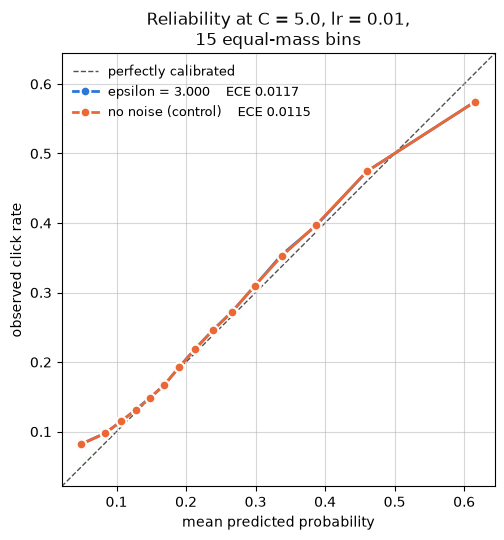

private: 15 bins kept, 13,333-13,334 records each, largest gap 0.0412
control: 15 bins kept, 13,333-13,334 records each, largest gap 0.0411


In [10]:
best_curve = reliability_curve(best.probs, Y_TEST, n_bins=N_BINS)
ctrl_curve = reliability_curve(ctrl.probs, Y_TEST, n_bins=N_BINS)

points = np.concatenate([best_curve.mean_predicted, best_curve.mean_observed,
                         ctrl_curve.mean_predicted, ctrl_curve.mean_observed])
pad = 0.05 * (points.max() - points.min())
lo, hi = points.min() - pad, points.max() + pad

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1, color=MUTED,
        zorder=1, label="perfectly calibrated")

# Identity is in the legend rather than at the end of each line: the two
# curves are expected to sit almost on top of each other and on the
# diagonal, which is where a direct label stops being readable.
for reliability, colour, label in (
    (best_curve, PRIVATE_C, f"epsilon = {spent:.3f}    ECE {best.ece:.4f}"),
    (ctrl_curve, CONTROL_C, f"no noise (control)    ECE {ctrl.ece:.4f}"),
):
    ax.plot(reliability.mean_predicted, reliability.mean_observed, marker="o",
            markersize=7, linewidth=2, color=colour, label=label,
            markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=2)

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal")
ax.set_xlabel("mean predicted probability")
ax.set_ylabel("observed click rate")
ax.set_title(f"Reliability at C = {BEST_C}, lr = {BEST_LR},\n"
             f"{N_BINS} equal-mass bins", color=INK)
ax.grid(alpha=0.5)
ax.legend(loc="upper left", frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

print(f"private: {len(best_curve.count)} bins kept, "
      f"{best_curve.count.min():,}-{best_curve.count.max():,} records each, "
      f"largest gap {np.abs(best_curve.gap).max():.4f}")
print(f"control: {len(ctrl_curve.count)} bins kept, "
      f"{ctrl_curve.count.min():,}-{ctrl_curve.count.max():,} records each, "
      f"largest gap {np.abs(ctrl_curve.gap).max():.4f}")

## 5. The best configuration over training steps

Hold `C`, the learning rate and the noise multiplier at the values section 4
picked, and vary only how long the run trains; log-loss, ECE and recall are on
three scales, so they get a panel each. **Each point is an independent run**
from the same initialization with its own noise draw — `train` returns no
optimizer state precisely so that a run cannot be resumed and replay its noise
stream.

The multiplier stays the one calibrated for 10,000 steps, so the shorter runs
are *over*-noised for their length and spend correspondingly less ε. The ε each
point actually spends is in the table.

In [11]:
step_grid = [50, 100, 200, 500, 1000, 2000, 4000, 7000, 10_000]
curve = []
print(f"{'steps':>7} {'epsilon':>8}  {COLUMNS} {'prec':>7} {'recall':>7}")
for steps in step_grid:
    result = run(steps=steps, clip_norm=BEST_C, learning_rate=BEST_LR,
                 noise_multiplier=sigma)
    eps = poisson_gaussian_epsilon(q, sigma, steps, TARGET_DELTA)
    precision, recall = rates(result.confusion)
    curve.append((steps, eps, result))
    print(f"{steps:>7,} {eps:>8.3f}  "
          f"{result.loss:9.4f} {result.ne:7.4f} {result.ece:7.4f} "
          f"{result.cal_ratio:10.4f} {result.pr_auc:7.4f} "
          f"{precision:7.4f} {recall:7.4f}")

  steps  epsilon   log-loss      NE     ECE  cal-ratio  PR-AUC    prec  recall


     50    2.075     0.6483  1.1484  0.2188     0.5353  0.4116  0.2520  1.0000
    100    2.125     0.6190  1.0965  0.1939     0.5651  0.4194  0.2520  1.0000
    200    2.182     0.5818  1.0306  0.1538     0.6210  0.4251  0.2559  0.9956
    500    2.274     0.5363  0.9500  0.0817     0.7551  0.4323  0.3058  0.8858
  1,000    2.360     0.5190  0.9193  0.0331     0.8838  0.4370  0.3585  0.7432
  2,000    2.475     0.5146  0.9116  0.0107     0.9870  0.4404  0.3857  0.6537
  4,000    2.641     0.5144  0.9112  0.0113     1.0215  0.4431  0.3938  0.6325
  7,000    2.832     0.5142  0.9109  0.0113     1.0218  0.4450  0.3948  0.6332
 10,000    3.000     0.5140  0.9106  0.0117     1.0242  0.4460  0.3960  0.6319


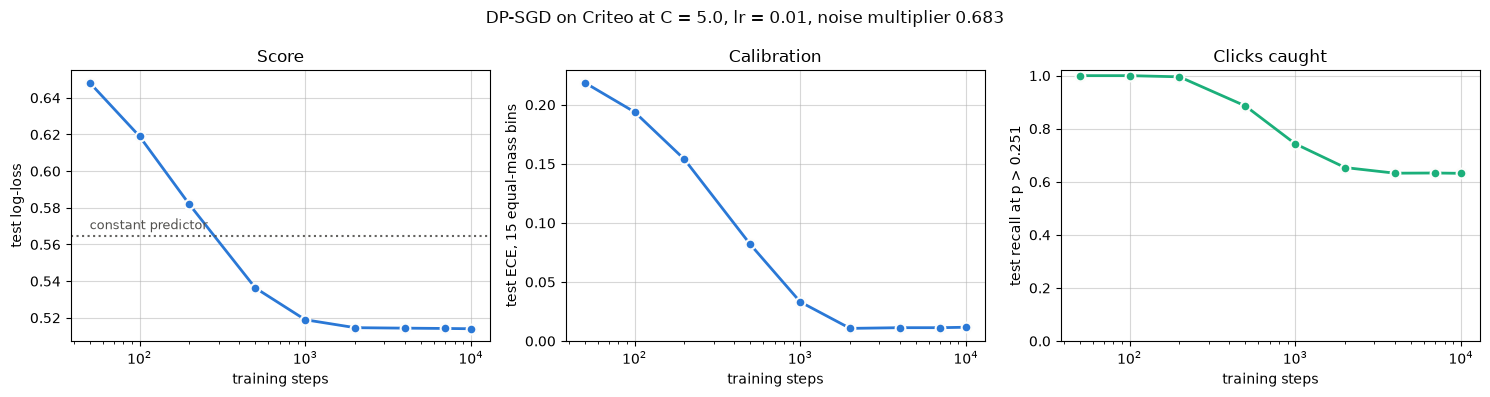

In [12]:
steps_axis = [point[0] for point in curve]
results = [point[2] for point in curve]

fig, (left, middle, right) = plt.subplots(1, 3, figsize=(15, 4))

left.plot(steps_axis, [r.loss for r in results], marker="o", markersize=7,
          linewidth=2, color=LOSS_C, markeredgecolor=SURFACE,
          markeredgewidth=1.5)
left.axhline(CONST_LOSS, color=MUTED, linestyle=":", alpha=0.9)
left.annotate("constant predictor", xy=(step_grid[0], CONST_LOSS),
              xytext=(0, 5), textcoords="offset points", color=MUTED,
              fontsize=9)
left.set_ylabel("test log-loss")
left.set_title("Score")

# ECE is an upward-biased estimate, so the distance from zero is not a
# calibration error and only the movement across this panel is readable --
# every point is the same n_bins on the same evaluation set.
middle.plot(steps_axis, [r.ece for r in results], marker="o", markersize=7,
            linewidth=2, color=ECE_C, markeredgecolor=SURFACE,
            markeredgewidth=1.5)
middle.set_ylabel(f"test ECE, {N_BINS} equal-mass bins")
middle.set_title("Calibration")
middle.set_ylim(bottom=0.0)

right.plot(steps_axis, [rates(r.confusion)[1] for r in results], marker="o",
           markersize=7, linewidth=2, color=RECALL_C,
           markeredgecolor=SURFACE, markeredgewidth=1.5)
right.set_ylabel(f"test recall at p > {THRESHOLD:.3f}")
right.set_title("Clicks caught")
# A rate gets its own scale. Autoscaling this panel would fill the frame with
# the seed-to-seed wobble in the converged tail and draw it as a trend.
right.set_ylim(0.0, 1.02)

for axis in (left, middle, right):
    axis.set_xlabel("training steps")
    axis.set_xscale("log")
    axis.grid(alpha=0.5)

fig.suptitle(f"DP-SGD on Criteo at C = {BEST_C}, lr = {BEST_LR}, "
             f"noise multiplier {sigma:.3f}", color=INK)
fig.tight_layout()
plt.show()

### Reading those three panels

**The run is essentially finished by 2,000 steps.** Log-loss falls
0.6483 → 0.5146 over the first 2,000 and then moves in the fourth decimal for
the remaining 8,000. Note the logarithmic x-axis: on a linear one all of this
happens inside the first pixel.

**Recall falls, and that is the model improving.** At 50 steps the parameters
have barely left their initialization, every record scores above the base-rate
threshold, and recall is 1.000 at precision 0.252 — flagging everyone, which is
what a model that knows nothing does at this threshold. By 2,000 steps it
catches 65% of the clicks at 39% precision, and the log-loss panel confirms the
move as an improvement.

**The later steps cost privacy and buy little.** From 2,000 to 10,000 steps ε
climbs 2.475 → 3.000 and log-loss improves by 0.0006. Two things keep that from
being a general claim: the multiplier is calibrated for 10,000 steps, so a run
actually targeting ε = 2.475 would use a smaller one and land above its point
here, and PR-AUC, which these panels do not show, is still creeping upward late
— 0.4404 at 2,000 steps against 0.4460 at 10,000.

## What this shows, and what it does not

DP-SGD end to end on 800,000 real Criteo rows and all 39 features: the loader,
the accountant in both directions (calibrate, then report, agreeing to
floating point), the training loop and the reference model.

At ε = 3, δ = 1e-6 over 10,000 steps, the selected configuration — `C = 5.0`,
`lr = 0.01` — reaches test log-loss 0.5140 against the constant predictor's
0.5645, normalized entropy 0.9106, ECE 0.0117, and PR-AUC 0.4460 against a
base-rate floor of 0.2520. The noiseless control lands on the same log-loss and
the same PR-AUC, so what costs utility at this budget is the clipping. At the
base-rate threshold the private model catches 31,848 of the 50,400 test clicks
and raises 48,586 false alarms.

Not shown, and not claimed:

- One algorithm, and no non-private baseline.
- **The preprocessing statistics are unaccounted** (ADR-0008); the ε above
  covers the training loop only.
- **The nine-run search is unaccounted**, and its winner was picked on the test
  split, so the reported figures are optimistic as held-out estimates as well
  as unpaid for as a privacy matter.
- **The operating point is a choice.** Every confusion matrix thresholds at the
  training base rate; a different threshold gives different precision and
  recall from the same model, while the ranking does not move.
- **No feature-norm bound.** Nothing caps row norms here, which is available
  only because clipping is what bounds DP-SGD's sensitivity.
- **One seed.** Every run above is `seed=0`, so none of the gaps come with an
  error bar.
- **The ε is RDP's** (ADR-0011); PLD would report a smaller number for the same
  run.